# Compras públicas com preço atípico e previsão do preço esperado

**Projeto Final de Machine Learning Clássico**
**Tema 5.4: Compras.gov.br, compra atípica e preço esperado**

Alunos: Mateo Zapelini e Miguel Torres
Professor: Rodrigo Ramos Silva

**Base:** API de Dados Abertos do Compras.gov.br, módulo de Pesquisa de Preço. São 1.350 compras
reais de *papel para impressão* (PDM 19746 do catálogo CATMAT), feitas por órgãos federais, estaduais
e municipais. São as compras mais recentes de 2025 devolvidas pela API, de 8 de agosto a 31 de
dezembro de 2025.

**Pergunta:** quais compras merecem revisão por terem preço fora do padrão de itens comparáveis?

**O que o projeto faz:** primeiro classifica quais compras têm perfil de risco de sair com preço atípico,
depois estima o preço esperado de cada compra, e no fim junta as duas coisas numa fila de revisão
ordenada pelo dinheiro que pode ter sido pago a mais.

**Aviso importante:** o projeto não fala em fraude. Uma compra "atípica" é só uma compra cujo preço
foge do padrão e que, por isso, merece ser olhada por uma pessoa. Muitas vezes a explicação é um
erro de cadastro, um frete caro ou um item diferente.

## 1. Carregamento dos dados

O arquivo `compras_papel_2025.csv` foi montado a partir da API
`https://dadosabertos.compras.gov.br/modulo-pesquisa-preco/1_consultarMaterial`, filtrando pelo
PDM 19746 (papel para impressão formatado) e pelo ano de 2025. Foram usadas as 18 primeiras páginas de
75 registros que a API devolve (1.350 compras), que cobrem de agosto a dezembro. Acesso em 25/09/2026. As características de cada papel (tipo, tamanho,
gramatura e cor) vieram do catálogo de materiais, rota `/modulo-material/4_consultarItemMaterial`.

No Colab, se o arquivo ainda não estiver na pasta, a célula abre uma janela para enviá-lo.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 30)
SEED = 42
ARQUIVO = 'compras_papel_2025.csv'

if not os.path.exists(ARQUIVO):
    try:
        from google.colab import files
        files.upload()   # escolha o arquivo compras_papel_2025.csv
    except ImportError:
        raise FileNotFoundError('Coloque o arquivo compras_papel_2025.csv na mesma pasta do notebook.')

df = pd.read_csv(ARQUIVO, dtype={'codigoItemCatalogo': str, 'codigoUasg': str, 'niFornecedor': str})
os.makedirs('figuras', exist_ok=True)
print(df.shape)
df.head()

(1350, 18)


,idItemCompra,codigoItemCatalogo,dataCompra,modalidade,forma,criterioJulgamento,quantidade,precoUnitario,siglaUnidadeFornecimento,capacidadeUnidadeFornecimento,estado,esfera,codigoUasg,niFornecedor,tipo_papel,tamanho,gramatura,cor
0,12667844,461889,2025-10-29,6,SISPP,1,100.0,25.80,EMB,500.0,RJ,M,985891,10542335000195,SULFITE/APERGAMINHADO/OFÍCIO,297 X 210 MM,75 G/M2,BRANCO
1,10808715,461878,2025-11-06,6,SISPP,1,25.0,31.96,EMB,10.0,DF,F,720300,44181200000163,TEXTURIZADO,297 X 210 MM,180 G/M2,BRANCO
2,10808722,461771,2025-11-06,6,SISPP,1,20.0,36.83,EMB,50.0,DF,F,720300,55808167000175,COUCHÊ,297 X 210 MM,180 G/M2,BRANCO
3,10808758,461771,2025-11-06,6,SISPP,1,10.0,28.62,EMB,50.0,DF,F,720300,55808167000175,COUCHÊ,297 X 210 MM,180 G/M2,BRANCO
4,10788003,461828,2025-11-27,6,SISPP,1,228.0,19.70,EMB,500.0,SP,E,392701,08822824000159,SULFITE/APERGAMINHADO/OFÍCIO,297 X 210 MM,75 G/M2,BRANCO


### 1.1 (Opcional) Coleta direta pela API

A função abaixo baixa a mesma consulta direto do Compras.gov.br, para quem quiser atualizar a base ou
ampliar o período. Ela não é executada por padrão, para que os números do relatório se repitam
exatamente. Para usar, troque `COLETAR_DA_API` para `True`.

In [2]:
COLETAR_DA_API = False

def coletar_precos(pdm='19746', inicio='2025-01-01', fim='2025-12-31', tamanho_pagina=500):
    import io, time, requests
    url = 'https://dadosabertos.compras.gov.br/modulo-pesquisa-preco/1.1_consultarMaterial_CSV'
    partes, pagina = [], 1
    while True:
        params = {'tipo': 'codigoPdm', 'codigo': pdm, 'dataCompraInicio': inicio,
                  'dataCompraFim': fim, 'pagina': pagina, 'tamanhoPagina': tamanho_pagina}
        r = requests.get(url, params=params, timeout=120)
        r.raise_for_status()
        parte = pd.read_csv(io.StringIO(r.text), sep=';', decimal=',', thousands='.', dtype=str)
        if parte.empty:
            break
        partes.append(parte)
        if len(parte) < tamanho_pagina:
            break
        pagina += 1
        time.sleep(1)
    return pd.concat(partes, ignore_index=True)

if COLETAR_DA_API:
    bruto = coletar_precos()
    print(bruto.shape)

### 1.2 Dicionário das variáveis

| Coluna | Significado |
|---|---|
| idItemCompra | identificador do item de compra |
| codigoItemCatalogo | código CATMAT do papel comprado |
| dataCompra | data da compra |
| modalidade | 5 = pregão, 6 = dispensa, 7 = inexigibilidade |
| forma | SISRP = registro de preços (ata), SISPP = compra comum |
| criterioJulgamento | código do critério de julgamento |
| quantidade | quantidade comprada, na unidade de fornecimento |
| precoUnitario | preço pago por unidade de fornecimento (R$) |
| siglaUnidadeFornecimento | EMB = embalagem (resma, pacote) ou FL = folha |
| capacidadeUnidadeFornecimento | folhas por embalagem (0 quando a unidade é a folha) |
| estado, esfera | UF e esfera (F federal, E estadual, M municipal) do órgão |
| codigoUasg, niFornecedor | unidade compradora e CNPJ do fornecedor |
| tipo_papel, tamanho, gramatura, cor | características do papel, tiradas do catálogo |

## 2. Análise Exploratória de Dados (EDA)

### 2.1 Tipos de dados, valores nulos e duplicatas

In [3]:
df.info()
print()
print('Valores ausentes por coluna:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print(f'Total de dados nulos: {df.isnull().sum().sum()}')
print(f'Linhas duplicadas (todas as colunas): {df.duplicated().sum()}')
print(f'Itens de compra repetidos (idItemCompra): {df["idItemCompra"].duplicated().sum()}')
print(f'Período: {df["dataCompra"].min()} a {df["dataCompra"].max()}')

<class 'pandas.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   idItemCompra                   1350 non-null   int64  
 1   codigoItemCatalogo             1350 non-null   str    
 2   dataCompra                     1350 non-null   str    
 3   modalidade                     1350 non-null   int64  
 4   forma                          1350 non-null   str    
 5   criterioJulgamento             1332 non-null   str    
 6   quantidade                     1350 non-null   float64
 7   precoUnitario                  1350 non-null   float64
 8   siglaUnidadeFornecimento       1350 non-null   str    
 9   capacidadeUnidadeFornecimento  1350 non-null   float64
 10  estado                         1350 non-null   str    
 11  esfera                         1350 non-null   str    
 12  codigoUasg                     1350 non-null   str    
 13 

### 2.2 O preço bruto não é comparável

O mesmo item pode ser vendido por folha, por pacote de 50 folhas ou por resma de 500. Além disso,
uma folha A3 tem o dobro de papel de uma A4, e um papel de 180 g/m² pesa mais que um de 75 g/m².
Comparar o `precoUnitario` direto seria comparar laranja com caixa de laranja.

In [4]:
print(df[['quantidade', 'precoUnitario', 'capacidadeUnidadeFornecimento']].describe().round(2))
print()
print(df['siglaUnidadeFornecimento'].value_counts())
print()
print(df['capacidadeUnidadeFornecimento'].value_counts())
print()
print(df['tipo_papel'].value_counts())

       quantidade  precoUnitario  capacidadeUnidadeFornecimento
count     1350.00        1350.00                        1350.00
mean      4540.94         218.73                         354.54
std      27309.73        5432.65                         207.53
min          1.00           0.05                           0.00
25%         50.00          18.00                         100.00
50%        250.00          22.06                         500.00
75%       1100.00          30.00                         500.00
max     630276.00      198981.00                         500.00

siglaUnidadeFornecimento
EMB    1240
FL      110
Name: count, dtype: int64

capacidadeUnidadeFornecimento
500.0    894
50.0     144
100.0    127
0.0      109
250.0     39
20.0      13
10.0      10
150.0      6
125.0      5
30.0       3
Name: count, dtype: int64

tipo_papel
SULFITE/APERGAMINHADO/OFÍCIO    934
COUCHÊ                          155
OFFSET                          150
RECICLADO                        67
TEXTU

### 2.3 Normalização: preço por quilo de papel

Para comparar compras diferentes, convertemos tudo para **reais por quilo de papel**:

- área da folha (m²) = comprimento × largura, a partir do campo `tamanho`;
- folhas por unidade = capacidade da embalagem (ou 1, quando a unidade é a própria folha);
- quilos por unidade = folhas × área × gramatura ÷ 1000;
- **preço por kg = preço unitário ÷ quilos por unidade**.

Exemplo: uma resma A4 de 75 g/m² tem 500 × 0,0624 m² × 75 g = 2,34 kg. Se custou R$ 20,00, o preço é
R$ 8,55 por kg.

In [5]:
medidas = df['tamanho'].str.extract(r'(\d+) X (\d+)').astype(float)
df['area_m2'] = medidas[0] * medidas[1] / 1_000_000
df['gramatura_g'] = df['gramatura'].str.extract(r'(\d+)').astype(float)[0]
df['folhas_unid'] = np.where(df['capacidadeUnidadeFornecimento'] > 0,
                             df['capacidadeUnidadeFornecimento'], 1)
df['kg_unid'] = df['folhas_unid'] * df['area_m2'] * df['gramatura_g'] / 1000
df['preco_kg'] = df['precoUnitario'] / df['kg_unid']
df['valor_total'] = df['precoUnitario'] * df['quantidade']

print(df['preco_kg'].describe(percentiles=[.05, .25, .5, .75, .95]).round(2))
print()
print(df.groupby('tipo_papel')['preco_kg'].describe(percentiles=[.25, .5, .75]).round(2))

count      1350.00
mean        716.17
std       13233.18
min           0.05
5%            6.72
25%           8.88
50%          10.90
75%          18.27
95%         141.85
max      447990.64
Name: preco_kg, dtype: float64

                              count     mean       std   min    25%    50%  \
tipo_papel                                                                   
COUCHÊ                        155.0  2928.44  35980.57  1.22  11.01  18.85   
OFFSET                        150.0   332.21   1208.93  0.05   9.65  11.65   
PERMANENTE                      2.0     7.48      4.23  4.49   5.99   7.48   
RECICLADO                      67.0    50.12    227.79  0.35   9.67  10.69   
SULFITE/APERGAMINHADO/OFÍCIO  934.0   484.64   6190.02  0.06   8.51  10.35   
TEXTURIZADO                    42.0   168.17    693.28  1.53  20.14  33.31   

                                75%        max  
tipo_papel                                      
COUCHÊ                        33.38  447990.64  
OFFSET

### 2.4 Grupos de comparação

Couchê e papel texturizado são naturalmente mais caros por quilo que o sulfite. Por isso cada
compra só é comparada com compras do mesmo tipo de papel. O tipo "Permanente" tem só 2 compras e
foi juntado com o texturizado no grupo de papéis especiais.

In [6]:
df['grupo_preco'] = df['tipo_papel'].replace({
    'SULFITE/APERGAMINHADO/OFÍCIO': 'SULFITE',
    'TEXTURIZADO': 'ESPECIAL',
    'PERMANENTE': 'ESPECIAL',
})
print(df['grupo_preco'].value_counts())

grupo_preco
SULFITE      934
COUCHÊ       155
OFFSET       150
RECICLADO     67
ESPECIAL      44
Name: count, dtype: int64


## 3. Divisão treino/teste e construção do alvo

### 3.1 Divisão

Separamos 20% das compras num "cofre" que o modelo nunca vê durante o treino. A divisão é
estratificada pelo grupo de preço, para que todos os tipos de papel apareçam nos dois lados.
A divisão é feita **antes** de criar o alvo, porque o limite de preço atípico também é aprendido só
com o treino.

In [7]:
from sklearn.model_selection import train_test_split

idx_tr, idx_te = train_test_split(df.index, test_size=0.20, random_state=SEED,
                                  stratify=df['grupo_preco'])
print(f'Treino: {len(idx_tr)} compras | Teste: {len(idx_te)} compras')

Treino: 1080 compras | Teste: 270 compras


### 3.2 Regra de compra atípica

Seguindo o guia do projeto, uma compra é **atípica** quando o preço por kg fica acima de
**Q3 + 1,5 × IQR** do seu grupo de comparação. Q1 e Q3 são o primeiro e o terceiro quartil, e
IQR = Q3 − Q1. É a mesma regra usada para marcar os pontos extremos de um boxplot.

Os quartis de cada grupo são calculados **somente com as compras de treino** e depois aplicados às
compras de teste.

In [8]:
limites = (df.loc[idx_tr].groupby('grupo_preco')['preco_kg']
             .quantile([.25, .5, .75]).unstack())
limites.columns = ['Q1', 'mediana', 'Q3']
limites['limite_atipico'] = limites['Q3'] + 1.5 * (limites['Q3'] - limites['Q1'])
print(limites.round(2))

df = df.join(limites[['mediana', 'limite_atipico']], on='grupo_preco')
df['compra_atipica'] = (df['preco_kg'] > df['limite_atipico']).astype(int)

print()
print(f'Atípicas na base toda: {df["compra_atipica"].sum()} ({df["compra_atipica"].mean()*100:.1f}%)')
print(f'  treino: {df.loc[idx_tr, "compra_atipica"].mean()*100:.1f}%   '
      f'teste: {df.loc[idx_te, "compra_atipica"].mean()*100:.1f}%')

                Q1  mediana     Q3  limite_atipico
grupo_preco                                       
COUCHÊ       11.26    19.43  34.38           69.05
ESPECIAL     20.15    32.96  47.57           88.69
OFFSET        9.65    11.54  33.20           68.54
RECICLADO     9.60    10.68  13.90           20.34
SULFITE       8.47    10.26  14.69           24.01

Atípicas na base toda: 180 (13.3%)
  treino: 13.5%   teste: 12.6%


### 3.3 Onde estão as compras atípicas

Olhamos a taxa de compras atípicas por unidade de fornecimento e por tipo de papel.
O `count` mostra quantas compras há em cada grupo. Grupos pequenos não são confiáveis.

In [9]:
print(df.groupby('siglaUnidadeFornecimento')['compra_atipica'].agg(['mean', 'count']).round(3))
print()
print(df.groupby('grupo_preco')['compra_atipica'].agg(['mean', 'count']).round(3))
print()
print(df.groupby('modalidade')['compra_atipica'].agg(['mean', 'count']).round(3))

                           mean  count
siglaUnidadeFornecimento              
EMB                       0.099   1240
FL                        0.518    110

              mean  count
grupo_preco              
COUCHÊ       0.097    155
ESPECIAL     0.091     44
OFFSET       0.180    150
RECICLADO    0.134     67
SULFITE      0.134    934

             mean  count
modalidade              
5           0.140    959
6           0.118    390
7           0.000      1


### 3.4 Visualizações do diagnóstico

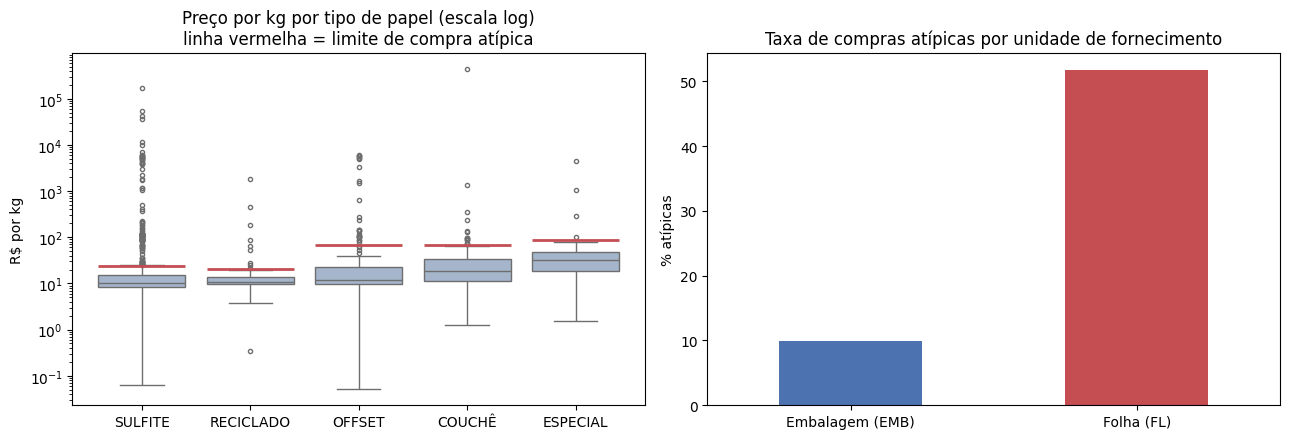

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ordem = ['SULFITE', 'RECICLADO', 'OFFSET', 'COUCHÊ', 'ESPECIAL']
sns.boxplot(data=df, x='grupo_preco', y='preco_kg', order=ordem, ax=axes[0],
            color='#9DB4D3', fliersize=3)
axes[0].set_yscale('log')
for i, g in enumerate(ordem):
    axes[0].hlines(limites.loc[g, 'limite_atipico'], i - 0.4, i + 0.4, colors='#C44E52', lw=2)
axes[0].set_title('Preço por kg por tipo de papel (escala log)\nlinha vermelha = limite de compra atípica')
axes[0].set_xlabel('')
axes[0].set_ylabel('R$ por kg')

taxa = df.groupby('siglaUnidadeFornecimento')['compra_atipica'].mean() * 100
taxa.index = ['Embalagem (EMB)', 'Folha (FL)']
taxa.plot.bar(ax=axes[1], color=['#4C72B0', '#C44E52'], rot=0)
axes[1].set_title('Taxa de compras atípicas por unidade de fornecimento')
axes[1].set_ylabel('% atípicas')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('figuras/fig1_eda.png', dpi=150)
plt.show()

## 4. Engenharia de atributos

A classificação não pode usar o preço, porque o alvo é feito a partir dele. Seria como "prever" a
resposta olhando a resposta. Então usamos só o que se sabe da compra **antes** de conhecer o preço
final: o que está sendo comprado, em que quantidade, de que forma e por quem.

Colunas novas:

- **regiao**: região do país, a partir da UF.
- **mes**: mês da compra.
- **log_quantidade** e **log_kg_total**: tamanho da compra em escala log, porque a quantidade vai de
  1 a mais de 600 mil.
- **unidade_folha**: 1 se o item foi cadastrado por folha. Na prática, esse cadastro costuma
  esconder uma resma registrada como se fosse uma folha.
- **formato_a4**: 1 se o tamanho é 297 × 210 mm.
- **cor_branca**: 1 se o papel é branco.
- **registro_precos**: 1 se a compra foi feita por ata de registro de preços (SISRP).
- **modalidade**: pregão ou contratação direta. A inexigibilidade tinha uma única compra e foi juntada
  com a dispensa, porque as duas são contratações sem disputa aberta.

In [11]:
REGIOES = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste',
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul',
}
df['regiao'] = df['estado'].map(REGIOES)
df['mes'] = pd.to_datetime(df['dataCompra']).dt.month
df['log_quantidade'] = np.log1p(df['quantidade'])
df['log_kg_total'] = np.log1p(df['quantidade'] * df['kg_unid'])
df['unidade_folha'] = (df['siglaUnidadeFornecimento'] == 'FL').astype(int)
df['formato_a4'] = (df['tamanho'] == '297 X 210 MM').astype(int)
df['cor_branca'] = (df['cor'] == 'BRANCO').astype(int)
df['registro_precos'] = (df['forma'] == 'SISRP').astype(int)
# 5 = pregão; 6 = dispensa e 7 = inexigibilidade (só 1 compra) viram "contratação direta"
df['modalidade'] = np.where(df['modalidade'] == 5, 'Pregao', 'Contratacao_direta')

NUMERICAS = ['area_m2', 'gramatura_g', 'folhas_unid', 'log_quantidade', 'log_kg_total', 'mes',
             'unidade_folha', 'formato_a4', 'cor_branca', 'registro_precos']
CATEGORICAS = ['grupo_preco', 'modalidade', 'esfera', 'regiao']

X = df[NUMERICAS + CATEGORICAS]
y = df['compra_atipica']
X_tr, X_te = X.loc[idx_tr], X.loc[idx_te]
y_tr, y_te = y.loc[idx_tr], y.loc[idx_te]
print(X_tr.shape, X_te.shape)
X_tr.head()

(1080, 14) (270, 14)


,area_m2,gramatura_g,folhas_unid,log_quantidade,log_kg_total,mes,unidade_folha,formato_a4,cor_branca,registro_precos,grupo_preco,modalidade,esfera,regiao
116,0.06237,75.0,500.0,7.090910,7.940103,12,0,1,1,1,SULFITE,Pregao,F,Sudeste
659,0.06237,180.0,50.0,4.262680,3.696180,10,0,1,1,1,SULFITE,Pregao,E,Norte
714,0.06237,75.0,500.0,8.922792,9.772385,10,0,1,1,1,SULFITE,Pregao,F,Sudeste
408,0.06237,75.0,500.0,6.580639,7.429515,11,0,1,0,0,SULFITE,Contratacao_direta,F,Sul
1083,0.06237,75.0,500.0,1.098612,1.736555,9,0,1,0,0,COUCHÊ,Contratacao_direta,E,Sudeste


### 4.1 Padronização e codificação

**StandardScaler nas numéricas.** Coloca todas as colunas na mesma régua, com média 0 e desvio 1.
Sem isso, a quantidade de folhas por embalagem (até 500) atropelaria a área da folha (menos de 1 m²).
Usamos o StandardScaler e não o MinMaxScaler porque há valores extremos, que fariam o MinMaxScaler
espremer quase todas as compras perto do zero.

**One-Hot nas categóricas.** Tipo de papel, modalidade, esfera e região são rótulos, não quantidades.
O One-Hot quebra cada coluna em várias colunas de 0 e 1.

Tudo fica dentro de um Pipeline, para a média e o desvio serem calculados só com o treino.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

prep = ColumnTransformer([
    ('num', StandardScaler(), NUMERICAS),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAS),
])
print(f'{len(NUMERICAS)} numéricas e {len(CATEGORICAS)} categóricas')

10 numéricas e 4 categóricas


## 5. Classificação: risco de compra atípica

Treinamos dois modelos que se contrastam. A **Regressão Logística** é linear e seus coeficientes
dão para explicar, o que importa na administração pública, porque o auditor precisa justificar por
que escolheu revisar uma compra. O **Random Forest** junta centenas de árvores e pega combinações
entre variáveis (por exemplo, unidade por folha junto com papel A4), mas perde a explicação simples.

O `class_weight='balanced'` faz o erro sobre as compras atípicas pesar mais. Sem isso o modelo
descobre que dizer "nenhuma compra é atípica" já acerta 87% e para de arriscar.

### 5.1 Ajuste dos hiperparâmetros

O GridSearchCV testa combinações e escolhe a melhor pelo F1 em validação cruzada de 5 partes, só com
o treino.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_lr = GridSearchCV(
    Pipeline([('prep', prep), ('clf', LogisticRegression(max_iter=5000, class_weight='balanced',
                                                         random_state=SEED))]),
    {'clf__C': [0.01, 0.1, 1.0, 10.0]},
    scoring='f1', cv=cv, n_jobs=-1)
grid_lr.fit(X_tr, y_tr)
print('Regressão Logística:', grid_lr.best_params_, f'F1 (validação) = {grid_lr.best_score_:.3f}')

# Para ficar rápido: a busca usa 100 árvores (basta para comparar as combinações) e o
# paralelismo fica só no GridSearchCV (n_jobs=-1 dentro do RF também só atrapalha).
# Depois da busca, o modelo escolhido é treinado de novo com 300 árvores.
grid_rf = GridSearchCV(
    Pipeline([('prep', prep), ('clf', RandomForestClassifier(n_estimators=100,
              class_weight='balanced_subsample', random_state=SEED))]),
    {'clf__max_depth': [4, 8, None], 'clf__min_samples_leaf': [1, 5, 10]},
    scoring='f1', cv=cv, n_jobs=-1)
grid_rf.fit(X_tr, y_tr)
print('Random Forest:', grid_rf.best_params_, f'F1 (validação, 100 árvores) = {grid_rf.best_score_:.3f}')
grid_rf.best_estimator_.set_params(clf__n_estimators=300).fit(X_tr, y_tr)   # modelo final

### 5.2 Avaliação no conjunto de teste

A métrica que decide é o F1, não a acurácia. Com só 13% de compras atípicas, um modelo que não
aponta nenhuma já acerta 87% e não serve para nada. O Recall diz quantas compras atípicas o modelo
pegou; a Precision diz quantas das compras apontadas eram mesmo atípicas.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

melhores = {'Regressão Logística': grid_lr.best_estimator_,
            'Random Forest': grid_rf.best_estimator_}
resultados = []
for nome, modelo in melhores.items():
    pred = modelo.predict(X_te)
    proba = modelo.predict_proba(X_te)[:, 1]
    resultados.append({'Modelo': nome,
                       'Acurácia': accuracy_score(y_te, pred),
                       'Precision': precision_score(y_te, pred),
                       'Recall': recall_score(y_te, pred),
                       'F1': f1_score(y_te, pred),
                       'ROC-AUC': roc_auc_score(y_te, proba),
                       '% apontadas': pred.mean()})
tabela_clf = pd.DataFrame(resultados).set_index('Modelo')
print((tabela_clf * 100).round(1))
for nome, modelo in melhores.items():
    print()
    print(nome)
    print(confusion_matrix(y_te, modelo.predict(X_te)))
print()
print(classification_report(y_te, grid_rf.best_estimator_.predict(X_te),
                            target_names=['Típica', 'Atípica']))

### 5.3 Gráficos de avaliação

In [ ]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for nome, modelo in melhores.items():
    proba = modelo.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f'{nome} (AUC={roc_auc_score(y_te, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório')
axes[0].set_xlabel('Taxa de falso positivo'); axes[0].set_ylabel('Taxa de verdadeiro positivo')
axes[0].set_title('Curva ROC'); axes[0].legend(fontsize=8)

for ax, (nome, modelo) in zip(axes[1:], melhores.items()):
    ConfusionMatrixDisplay.from_estimator(modelo, X_te, y_te, ax=ax, cmap='Blues', colorbar=False,
                                          display_labels=['Típica', 'Atípica'])
    ax.set_title(f'Matriz de confusão: {nome}')
    ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('figuras/fig2_classificacao.png', dpi=150)
plt.show()

### 5.4 Quais variáveis pesam mais

O Random Forest informa quanto cada coluna contribuiu para as decisões. A Regressão Logística mostra
o sinal: coeficiente positivo aumenta o risco, negativo diminui.

In [ ]:
rf_final = grid_rf.best_estimator_
nomes = rf_final.named_steps['prep'].get_feature_names_out()
nomes = [n.replace('num__', '').replace('cat__', '') for n in nomes]
imp = pd.Series(rf_final.named_steps['clf'].feature_importances_, index=nomes).sort_values(ascending=False)
print('TOP 10 - Random Forest\n')
print(imp.head(10).round(3).to_string())

coef = pd.Series(grid_lr.best_estimator_.named_steps['clf'].coef_[0], index=nomes)
print('\nMaiores coeficientes - Regressão Logística\n')
print(coef.reindex(coef.abs().sort_values(ascending=False).index).head(10).round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
imp.head(12).sort_values().plot.barh(ax=ax, color='#4C72B0')
ax.set_title('Random Forest: importância dos atributos')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('figuras/fig3_importancia.png', dpi=150)
plt.show()

## 6. Regressão: preço esperado

A classificação diz quais compras têm perfil de risco. Agora precisamos de uma referência: quanto
aquela compra **deveria** ter custado. Com isso dá para medir quanto foi pago acima do esperado.

- **Alvo:** preço por kg (R$/kg).
- **Treino:** só as compras típicas do treino. Se deixássemos as atípicas, o modelo aprenderia que
  preço absurdo é normal. É o mesmo raciocínio de uma pesquisa de preços, que descarta os valores
  discrepantes antes de calcular a referência.
- **Escala log:** o preço por kg é assimétrico, então o modelo aprende o log do preço e depois
  voltamos para reais. Os erros são medidos em R$/kg.
- **Modelos:** Regressão Linear Simples (só a gramatura, como linha de base), Linear Múltipla,
  Polinomial de grau 2 (com Ridge) e Random Forest Regressor.
- Todos usam o mesmo pré-processamento da classificação (padronização e One-Hot), dentro de um Pipeline.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import KFold

tipicas_tr = idx_tr[(df.loc[idx_tr, 'compra_atipica'] == 0).values]
tipicas_te = idx_te[(df.loc[idx_te, 'compra_atipica'] == 0).values]
Xr_tr, Xr_te = X.loc[tipicas_tr], X.loc[tipicas_te]
yr_tr, yr_te = df.loc[tipicas_tr, 'preco_kg'], df.loc[tipicas_te, 'preco_kg']
print(f'Compras típicas - treino: {len(tipicas_tr)} | teste: {len(tipicas_te)}')

def em_log(modelo):
    return TransformedTargetRegressor(regressor=modelo, func=np.log, inverse_func=np.exp)

prep_simples = ColumnTransformer([('num', StandardScaler(), ['gramatura_g'])])

modelos_reg = {
    'Linear Simples (gramatura)': em_log(Pipeline([('prep', prep_simples), ('reg', LinearRegression())])),
    'Linear Múltipla': em_log(Pipeline([('prep', prep), ('reg', LinearRegression())])),
}

# Os dois modelos com hiperparâmetros são ajustados com GridSearchCV (5 partes, só no treino),
# escolhendo pelo menor erro médio absoluto em R$/kg.
cv_reg = KFold(n_splits=5, shuffle=True, random_state=SEED)

grid_poly = GridSearchCV(
    em_log(Pipeline([('prep', prep), ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                     ('reg', Ridge())])),
    {'regressor__reg__alpha': [1, 10, 100, 1000]},
    scoring='neg_mean_absolute_error', cv=cv_reg, n_jobs=-1)
grid_poly.fit(Xr_tr, yr_tr)
print('Polinomial:', grid_poly.best_params_, f'MAE (validação) = {-grid_poly.best_score_:.2f}')

# Mesma ideia da classificação: busca com 100 árvores, paralelismo só no GridSearchCV e
# modelo final com 400 árvores.
grid_rfr = GridSearchCV(
    em_log(Pipeline([('prep', prep), ('reg', RandomForestRegressor(n_estimators=100,
                                                                   random_state=SEED))])),
    {'regressor__reg__min_samples_leaf': [1, 3, 5, 10], 'regressor__reg__max_features': [1.0, 0.5]},
    scoring='neg_mean_absolute_error', cv=cv_reg, n_jobs=-1)
grid_rfr.fit(Xr_tr, yr_tr)
print('Random Forest:', grid_rfr.best_params_, f'MAE (validação, 100 árvores) = {-grid_rfr.best_score_:.2f}')
grid_rfr.best_estimator_.set_params(regressor__reg__n_estimators=400).fit(Xr_tr, yr_tr)   # modelo final
print()

modelos_reg['Polinomial grau 2 (Ridge)'] = grid_poly.best_estimator_
modelos_reg['Random Forest Regressor'] = grid_rfr.best_estimator_

linhas = []
for nome, modelo in modelos_reg.items():
    if nome in ('Linear Simples (gramatura)', 'Linear Múltipla'):   # os do grid já saem treinados
        modelo.fit(Xr_tr, yr_tr)
    pred = modelo.predict(Xr_te)
    linhas.append({'Modelo': nome,
                   'MAE (R$/kg)': mean_absolute_error(yr_te, pred),
                   'RMSE (R$/kg)': mean_squared_error(yr_te, pred) ** 0.5,
                   'Erro mediano (R$/kg)': np.median(np.abs(yr_te - pred)),
                   'MAPE (%)': mean_absolute_percentage_error(yr_te, pred) * 100,
                   'R²': r2_score(yr_te, pred)})
tabela_reg = pd.DataFrame(linhas).set_index('Modelo').sort_values('MAE (R$/kg)')
print(tabela_reg.round(3))

O erro mediano foi incluído porque não é afetado por um único erro gigante. A Polinomial é o caso
típico: numa compra rara (papel texturizado cadastrado por folha), os termos ao quadrado extrapolaram
e o preço previsto passou de R$ 680/kg. Esse único ponto derruba o R² dela, embora o erro mediano seja
parecido com o dos outros modelos.

In [ ]:
pred_poly = modelos_reg['Polinomial grau 2 (Ridge)'].predict(Xr_te)
pior = np.argmax(np.abs(pred_poly - yr_te.values))
print(f'Pior previsão da Polinomial: real R$ {yr_te.values[pior]:.2f}/kg, previsto R$ {pred_poly[pior]:.2f}/kg')
print(df.loc[yr_te.index[pior], ['tipo_papel', 'tamanho', 'gramatura', 'siglaUnidadeFornecimento']].to_string())
sem_pior = np.delete(np.arange(len(yr_te)), pior)
print(f'R² da Polinomial sem esse ponto: {r2_score(yr_te.values[sem_pior], pred_poly[sem_pior]):.3f}')

### 6.1 Preço real versus preço esperado

In [ ]:
melhor_reg_nome = tabela_reg.index[0]
reg_final = modelos_reg[melhor_reg_nome]
pred_te = reg_final.predict(Xr_te)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(yr_te, pred_te, s=14, alpha=.6, color='#4C72B0')
lim = [min(yr_te.min(), pred_te.min()) * .9, max(yr_te.max(), pred_te.max()) * 1.1]
axes[0].plot(lim, lim, 'k--', lw=1)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Preço real (R$/kg)'); axes[0].set_ylabel('Preço esperado (R$/kg)')
axes[0].set_title(f'{melhor_reg_nome}: real x esperado (compras típicas de teste)')

erro_pct = (pred_te - yr_te) / yr_te * 100
axes[1].hist(erro_pct, bins=40, color='#4C72B0')
axes[1].axvline(0, color='k', lw=1)
axes[1].set_xlabel('Erro (%)'); axes[1].set_ylabel('Compras')
axes[1].set_title('Distribuição do erro percentual')
plt.tight_layout()
plt.savefig('figuras/fig4_regressao.png', dpi=150)
plt.show()

a4 = df.loc[tipicas_te].query("grupo_preco == 'SULFITE' and formato_a4 == 1 and gramatura_g == 75")
print(f'Resma A4 75 g/m² (2,34 kg): preço real mediano R$ {a4["preco_kg"].median()*2.339:.2f} | '
      f'esperado mediano R$ {np.median(reg_final.predict(X.loc[a4.index]))*2.339:.2f}')

## 7. Juntando as duas etapas: a fila de revisão

A classificação dá a **probabilidade** de a compra ser atípica. A regressão dá o **preço esperado**.
Com o preço esperado calculamos o **valor pago acima do esperado**:

`sobrepreço estimado = max(0, preço pago − preço esperado) × quantidade`

O **valor em risco** de cada compra é a probabilidade vezes esse sobrepreço. Ordenando por ele, a
equipe de controle interno revisa primeiro as compras que juntam perfil de risco e mais dinheiro
em jogo.

Cuidado: o sobrepreço usa o preço pago, que também define o rótulo. Então é natural que o topo da
fila tenha muitas compras atípicas. O ganho da fila está em ordenar pelo dinheiro envolvido, não em
"descobrir" a atipicidade.

In [ ]:
teste = df.loc[idx_te].copy()
teste['p_atipica'] = rf_final.predict_proba(X_te)[:, 1]
teste['preco_kg_esperado'] = reg_final.predict(X_te)
teste['preco_unit_esperado'] = teste['preco_kg_esperado'] * teste['kg_unid']
teste['sobrepreco_estimado'] = ((teste['precoUnitario'] - teste['preco_unit_esperado']).clip(lower=0)
                                * teste['quantidade'])
teste['valor_em_risco'] = teste['p_atipica'] * teste['sobrepreco_estimado']
fila = teste.sort_values('valor_em_risco', ascending=False)

top10 = fila.head(int(round(len(fila) * 0.10)))
print(f'Compras na base de teste      : {len(fila)}')
print(f'Valor total das compras       : R$ {fila["valor_total"].sum():,.0f}')
print(f'Sobrepreço estimado total     : R$ {fila["sobrepreco_estimado"].sum():,.0f}')
print(f'Valor em risco total          : R$ {fila["valor_em_risco"].sum():,.0f}')
print(f'Parcela do valor em risco nos 10% do topo: '
      f'{top10["valor_em_risco"].sum() / fila["valor_em_risco"].sum() * 100:.1f}%')
print()
print(f'Atípicas nos 10% do topo: {top10["compra_atipica"].mean()*100:.1f}% '
      f'(base de teste: {fila["compra_atipica"].mean()*100:.1f}%)  '
      f'lift = {top10["compra_atipica"].mean() / fila["compra_atipica"].mean():.1f}x')
print()
# Quanto o preço pago ficou acima do esperado, nas compras do topo da fila
top10 = top10.assign(razao=top10['precoUnitario'] / top10['preco_unit_esperado'])
erro_unidade = (top10['razao'] >= 5).sum()
moderado = ((top10['razao'] >= 1.5) & (top10['razao'] < 5)).sum()
print(f'No topo da fila ({len(top10)} compras):')
print(f'  preço pago 5 vezes ou mais acima do esperado (provável erro de unidade): {erro_unidade}')
print(f'  preço pago entre 1,5 e 5 vezes o esperado (possível sobrepreço real)  : {moderado}')
print(f'  preço até 1,5 vez o esperado                                          : {len(top10) - erro_unidade - moderado}')
print()
cols = ['dataCompra', 'estado', 'esfera', 'tipo_papel', 'siglaUnidadeFornecimento', 'quantidade',
        'precoUnitario', 'preco_unit_esperado', 'p_atipica', 'valor_em_risco']
fila[cols].head(10).round(2)

## 8. (Opcional) K-Means: perfis de compra

O K-Means não tem alvo. Aqui ele agrupa as compras por três medidas, para ver que perfis existem:

- **preço relativo**: preço por kg dividido pela mediana do seu grupo (em log);
- **tamanho da compra**: quilos totais comprados (em log);
- **unidade por folha**: se o item foi cadastrado por folha.

O número de grupos foi escolhido pelo coeficiente de silhueta.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

km_df = pd.DataFrame({
    'log_preco_relativo': np.log(df['preco_kg'] / df['mediana']),
    'log_kg_total': df['log_kg_total'],
    'unidade_folha': df['unidade_folha'],
})
Z = StandardScaler().fit_transform(km_df)

sil = {}
for k in range(2, 7):
    rotulos = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(Z)
    sil[k] = silhouette_score(Z, rotulos)
print('Silhueta por k:', {k: round(v, 3) for k, v in sil.items()})

K = max(sil, key=sil.get)
df['cluster'] = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(Z)
perfil = df.groupby('cluster').agg(
    compras=('preco_kg', 'size'),
    preco_relativo_mediano=('preco_kg', lambda s: (s / df.loc[s.index, 'mediana']).median()),
    kg_total_mediano=('log_kg_total', lambda s: np.expm1(s).median()),
    pct_unidade_folha=('unidade_folha', 'mean'),
    pct_atipicas=('compra_atipica', 'mean'),
    pct_registro_precos=('registro_precos', 'mean'),
).round(2)
print(f'\nk escolhido = {K}\n')
print(perfil)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
sc = ax.scatter(km_df['log_kg_total'], km_df['log_preco_relativo'], c=df['cluster'], cmap='tab10',
                s=12, alpha=.7)
ax.axhline(0, color='k', lw=.8)
ax.set_xlabel('log(1 + kg total comprados)'); ax.set_ylabel('log(preço / mediana do grupo)')
ax.set_title(f'K-Means com k = {K}')
ax.legend(*sc.legend_elements(), title='Cluster', fontsize=8)
plt.tight_layout()
plt.savefig('figuras/fig5_kmeans.png', dpi=150)
plt.show()

## 9. Conclusão

### Melhor modelo de classificação

O **Random Forest**, com F1 de 0,583 e ROC-AUC de 0,917, contra 0,490 e 0,874 da Regressão Logística.
A Logística teve Recall maior (73,5% contra 61,8%), mas porque aponta muito mais compras: 25% da base
de teste, contra 14% do Random Forest. Numa equipe de controle com tempo limitado, apontar uma em cada
quatro compras gera trabalho demais com alarmes falsos. O F1 equilibra as duas coisas, e nele o Random
Forest foi melhor. A Logística continua útil quando é preciso explicar a decisão.

### Melhor modelo de regressão

O **Random Forest Regressor**, com erro médio de R$ 2,78/kg, erro mediano de R$ 0,87/kg e R² de 0,580.
A Linear Múltipla ficou em R$ 3,98/kg e R² de 0,332. A Polinomial teve erro mediano razoável, mas
explodiu numa compra rara e ficou com R² negativo, o que mostra o risco de extrapolar com termos ao
quadrado. Para a resma A4 de 75 g/m², o modelo estima R$ 22,90, contra R$ 23,14 do preço real mediano.

### Variáveis que mais pesam

Quilos totais comprados, folhas por embalagem, quantidade e unidade por folha. Todas descrevem **como
a quantidade e a unidade foram cadastradas**. O sinal mais forte de preço atípico não é o estado, a
esfera ou a modalidade: é a unidade de fornecimento não bater com o preço. Uma resma registrada como
"folha" ou uma caixa com 10 resmas registrada como "embalagem de 10 folhas" fazem o preço por kg
explodir.

### Recomendação prática

Juntando as duas etapas, cada compra ganha um valor em risco: a chance de ser atípica vezes o valor
pago acima do esperado. Na base de teste, os 10% do topo da fila concentram 97,9% do valor em risco, e
81,5% dessas compras são atípicas, contra 12,6% na base toda (6,5 vezes mais).

Das 27 compras do topo, 20 têm preço 5 vezes ou mais acima do esperado, o que quase sempre indica erro
de unidade no cadastro, e não sobrepreço de verdade. Então a recomendação tem duas partes:

1. **Na entrada dos dados:** validar a unidade de fornecimento e a capacidade da embalagem quando o
   preço por kg sai muito do padrão. Isso limpa a base de preços que todo o governo usa como referência.
2. **Na revisão:** mandar para análise humana as compras do topo da fila que não forem erro de unidade,
   que são as candidatas a sobrepreço real.

O modelo não acusa ninguém. Ele só organiza o que deve ser olhado primeiro.

### Limitações

A base cobre só cinco meses e um tipo de item. O rótulo vem de uma regra estatística (Q3 + 1,5 × IQR),
então o modelo aprende essa regra, e compra atípica não é o mesmo que compra irregular. O sobrepreço
estimado está inflado por erros de cadastro e não é prejuízo real. A base não tem frete, prazo de
entrega nem marca exigida, que também explicam diferenças de preço. E o modelo mostra associação,
não causa.

### Ambiente de execução

Python 3 com pandas, numpy, scikit-learn, matplotlib e seaborn. Roda no Google Colab, sem GPU, em poucos
minutos. Semente aleatória fixada em 42, então os números se repetem a cada execução, desde que se use
o arquivo `compras_papel_2025.csv` que acompanha o notebook.